In [34]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

366 exons x 125 samples
NaN cells: 6292 (0.138)
Saved: ../outputs/exon_psi_heatmap.png | ../outputs/exon_psi_heatmap.svg


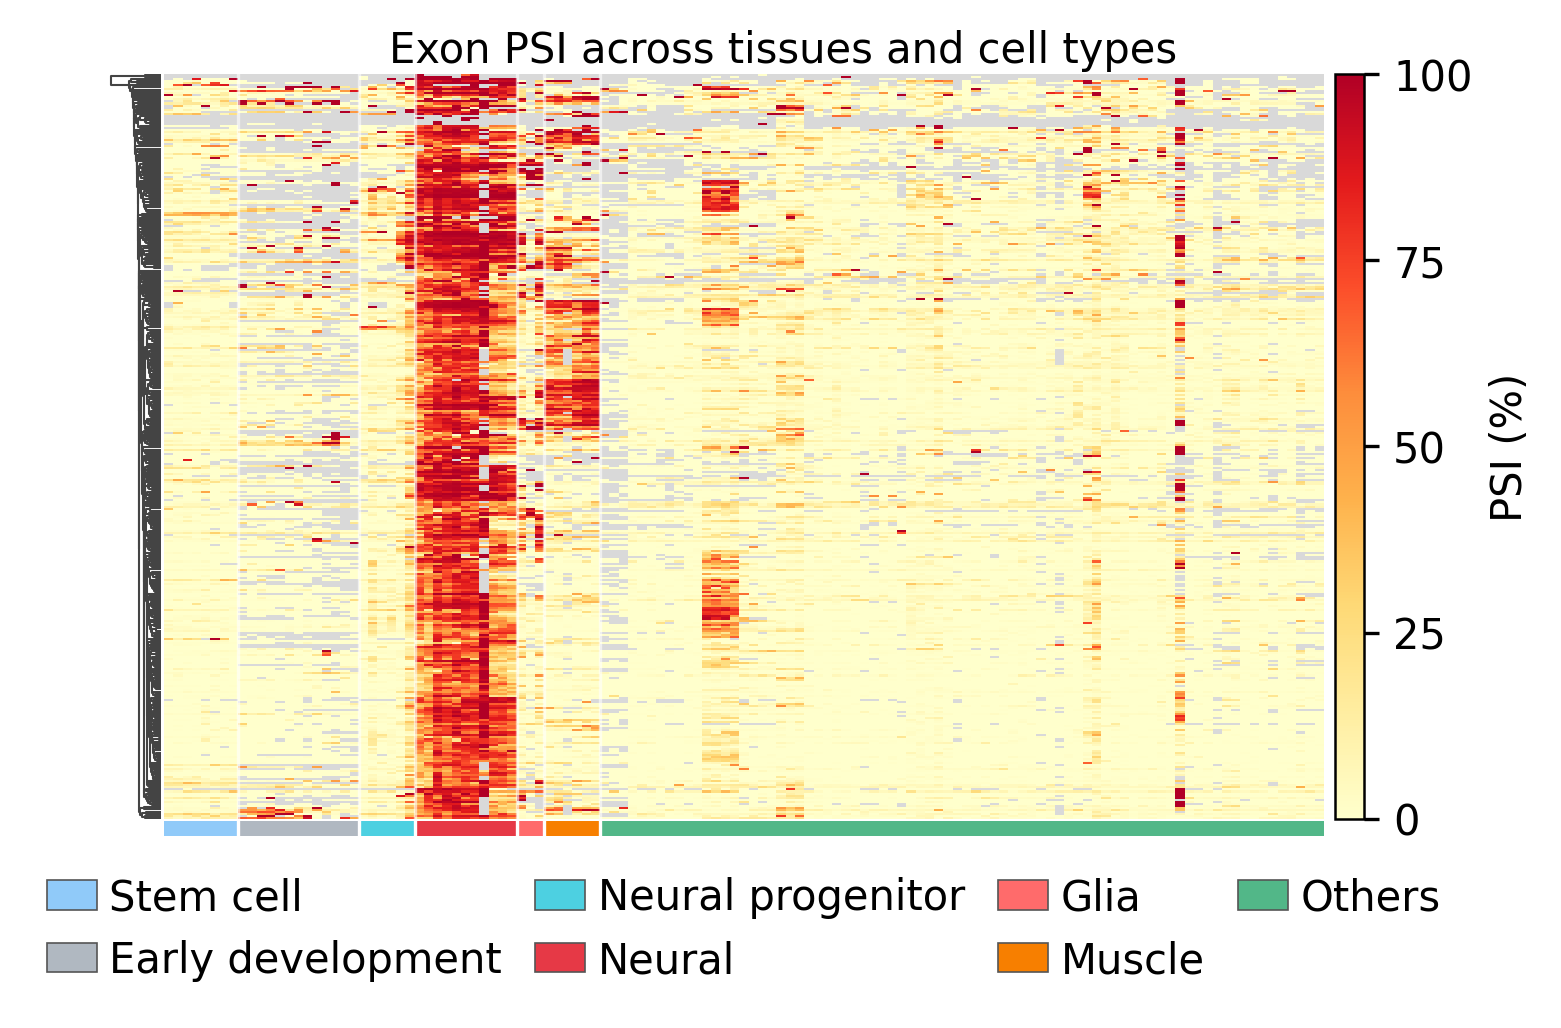

In [35]:
# ---- Config ----
CSV_PATH = "../outputs/neuron_up_exon_conserved.csv"               # <-- change to your path
OUT_PNG  = "../outputs/exon_psi_heatmap.png"
OUT_SVG  = "../outputs/exon_psi_heatmap.svg"
PSI_START_COL = "Whole_Brain_b"
PSI_END_COL   = "ratio"

# ---- Colormap: Yellow-Orange-Red (YlOrRd), Cell-style sequential ----
COLORMAP = LinearSegmentedColormap.from_list(
    "ylorrd",
    ["#FFFFCC", "#FFEDA0", "#FED976", "#FEB24C",
     "#FD8D3C", "#FC4E2A", "#E31A1C", "#B10026"],
    N=256,
)
COLORMAP.set_bad("#d9d9d9")   # NaN -> light gray

# ---- 7 tissue groups (Neural crest -> progenitor) ----
TISSUE_GROUPS = [
    ("Stem cell", "#90caf9", [
        "ESC_H1_a","ESC_H1_b","ESC_H1_c","ESC_H1_d",
        "ESC_H9_a","ESC_H9_b","iPS_a","iPS_b",
    ]),
    ("Early development", "#b0b8c1", [
        "Oocyte_a_A","Zygote_a_A",
        "Embr_2C_a_A","Embr_2C_a_B",
        "Embr_4C_a_A","Embr_4C_a_B","Embr_4C_a_C",
        "Embr_8C_a_A","Embr_8C_a_B","Embr_8C_a_C","Embr_8C_a_D",
        "Embr_Morula_a_A","Embr_Morula_a_B",
    ]),
    ("Neural progenitor", "#4dd0e1", [
        "NCC_Cranial_c","NCC_default_b","NCC_Enteric_b","NCC_Melano_biased_b",
        "NPC_a","NPC_b",
    ]),
    ("Neural", "#e63946", [
        "Whole_Brain_b","Cortex","Frontal_Gyrus_young","Frontal_Gyrus_old",
        "Sup_Temporal_Gyrus","Cerebellum_a","Cerebellum_c","Neurons",
        "Neurons_Cortex_KCl_0h","Neurons_Cortex_KCl_1h","Neurons_Cortex_KCl_6h",
    ]),
    ("Glia", "#ff6b6b", [
        "Astrocytes","Microglia","Oligodendrocytes",
    ]),
    ("Muscle", "#f77f00", [
        "Heart_a","Heart_b","Heart_c",
        "Muscle_b","Muscle_d","Muscle_e",
    ]),
    ("Others", "#52b788", [
        "Embr_ICM_a_A","Embr_TE_a_A","Embr_TE_a_B",
        "Placenta_a","Placenta_b","Placenta_c","Decidua","Amnion","Chorion",
        "HFDPC","MSC",
        "Pancreas_Alpha_Old","Pancreas_Alpha_Young",
        "Pancreas_Beta_Old","Pancreas_Beta_Young",
        "Pancreas_Acinar_Old","Pancreas_Acinar_Young",
        "Pancreas_Duct_Old","Pancreas_Duct_Young",
        "Testis_a","Testis_b","Testis_c","Ovary_a","Ovary_b",
        "Skin_a","Skin_b","Skin_c","Skin_d","Placenta_Epith",
        "EpithelialCells","Breast_Epith_a","HMEpC_a",
        "Stomach_a","Stomach_b","Small_intestine",
        "Colon_b","Colon_sigmoid","Colon_transverse",
        "Liver_a","Liver_b","Liver_c",
        "Kidney_d","Kidney_e","Kidney_f",
        "Lung_b","Lung_e","Lung_f",
        "EndomStromCells","Adipose_b","Adipose_c","Adipose_d",
        "Breast_a","Adrenal_b","Adrenal_c",
        "Prostate_b","Prostate_c","Prostate_d",
        "Thyroid_b","Thyroid_c","Thyroid_d","Bladder_a",
        "EndothCells","Brain_Endoth","Melanocytes",
        "Fibroblasts","GLS_cells",
        "Bone_marrow_a","Bone_marrow_b","Bone_marrow_c",
        "Spleen_a","Spleen_b","Thymus_a","Thymus_b",
        "Lymph_node_b","Lymph_node_c","MonoNucCells",
        "WBC_d","WBC_e",
    ]),
]

# ---- Fonts: Arial, single size everywhere ----
FONT_SIZE = 10
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE, "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE, "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE, "legend.title_fontsize": FONT_SIZE,
    "figure.dpi": 300, "savefig.dpi": 300,
    "pdf.fonttype": 42, "ps.fonttype": 42, "axes.linewidth": 0.6,
})

# ---- Load + slice the 125 PSI columns ----
df = pd.read_csv(CSV_PATH)
cols = df.columns.tolist()
psi_cols = cols[cols.index(PSI_START_COL):cols.index(PSI_END_COL)]
psi = df[psi_cols].copy()
psi.index = df["GENE"].astype(str) + " (" + df["EVENT"].astype(str) + ")"
print(f"{psi.shape[0]} exons x {psi.shape[1]} samples")

# ---- Order columns by 7-group sequence ----
ordered_cols, col_colors, col_groups = [], [], []
for grp_name, grp_color, samples in TISSUE_GROUPS:
    for s in samples:
        if s in psi_cols:
            ordered_cols.append(s); col_colors.append(grp_color); col_groups.append(grp_name)
psi = psi[ordered_cols].astype(float)
print(f"NaN cells: {psi.isna().sum().sum()} ({psi.isna().sum().sum()/psi.size:.3f})")

# ---- Row clustering (mean-impute per row for distance only; display keeps NaN->gray) ----
psi_for_dist = psi.copy()
row_means = psi_for_dist.mean(axis=1, skipna=True)
for i, rm in enumerate(row_means):
    psi_for_dist.iloc[i] = psi_for_dist.iloc[i].fillna(rm if np.isfinite(rm) else 0.0)
row_linkage = linkage(pdist(psi_for_dist.values, metric="euclidean"), method="average")

# ---- Group spans (for separator lines + legend) ----
group_spans, prev_grp, start_idx = [], None, 0
for i, grp in enumerate(col_groups):
    if grp != prev_grp:
        if prev_grp is not None:
            group_spans.append((prev_grp, col_colors[start_idx], start_idx, i-1))
        start_idx = i; prev_grp = grp
group_spans.append((prev_grp, col_colors[start_idx], start_idx, len(col_groups)-1))

# ---- Plot (compact: heatmap just large enough for the bottom legend) ----
fig = plt.figure(figsize=(4.5, 3), facecolor="white")
gs = gridspec.GridSpec(3, 2, figure=fig,
                       width_ratios=[0.045, 1],
                       height_ratios=[1, 0.02, 0.085],
                       hspace=0.01, wspace=0.006)
ax_dendro  = fig.add_subplot(gs[0, 0])
ax_heatmap = fig.add_subplot(gs[0, 1])
ax_grp     = fig.add_subplot(gs[1, 1])
ax_legend  = fig.add_subplot(gs[2, 1:])

ddata = dendrogram(row_linkage, orientation="left", ax=ax_dendro,
                   no_labels=True, color_threshold=0,
                   link_color_func=lambda k: "#444444",
                  )
for line in ax_dendro.collections:
    line.set_linewidth(0.5)
ax_dendro.set_axis_off(); ax_dendro.invert_yaxis()
psi_ordered = psi.iloc[ddata["leaves"], :]

im = ax_heatmap.imshow(psi_ordered.values, aspect="auto", cmap=COLORMAP,
                       vmin=0, vmax=100, interpolation="nearest")
ax_heatmap.set_xticks([]); ax_heatmap.set_yticks([])
for sp in ax_heatmap.spines.values(): sp.set_visible(False)
for name, color, s, e in group_spans:
    if s > 0: ax_heatmap.axvline(x=s-0.5, color="white", linewidth=0.8, alpha=0.6)

cbar_ax = ax_heatmap.inset_axes([1.01, 0.0, 0.025, 1.0])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("PSI (%)"); cbar.outline.set_linewidth(0.6)
cbar.set_ticks([0, 25, 50, 75, 100])

grp_arr = np.array([[mcolors.to_rgb(c) for c in col_colors]])
ax_grp.imshow(grp_arr, aspect="auto", interpolation="nearest")
ax_grp.set_xticks([]); ax_grp.set_yticks([])
ax_grp.set_xlim(-0.5, len(col_colors)-0.5)
for sp in ax_grp.spines.values(): sp.set_visible(False)
for name, color, s, e in group_spans:
    if s > 0: ax_grp.axvline(x=s-0.5, color="white", linewidth=0.8)

ax_legend.set_axis_off()
handles = [mpatches.Patch(facecolor=color, label=name, edgecolor="#555555", linewidth=0.4)
           for name, color, _, _ in group_spans]
ax_legend.legend(handles=handles, loc="upper center", ncol=4,
                 frameon=False, handlelength=1.2, handletextpad=0.3,columnspacing=0.8)

fig.suptitle("Exon PSI across tissues and cell types",
             fontsize=FONT_SIZE, y=1.01)
plt.subplots_adjust(top=0.96, bottom=0.04, left = 0)

fig.savefig(OUT_PNG, bbox_inches="tight", facecolor="white")
fig.savefig(OUT_SVG, bbox_inches="tight", facecolor="white")
print(f"Saved: {OUT_PNG} | {OUT_SVG}")
plt.show()